In [2]:
import pandas as pd
df = pd.read_csv(r"E:\pradnya's programming\Domains\ML\DA_clgAss\ds_salaries.csv")
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


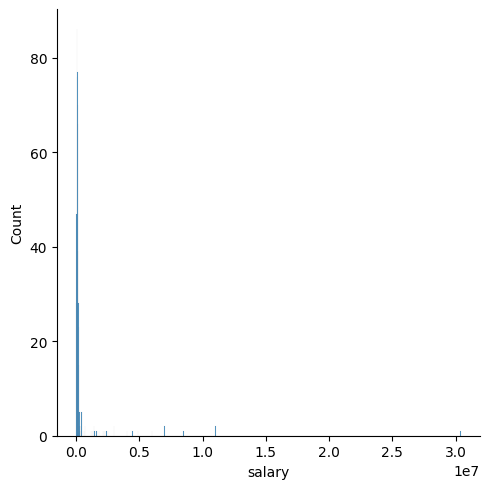

In [5]:
import seaborn as sns
sns.displot(df['salary'])

### Boxplot method

<Axes: ylabel='salary'>

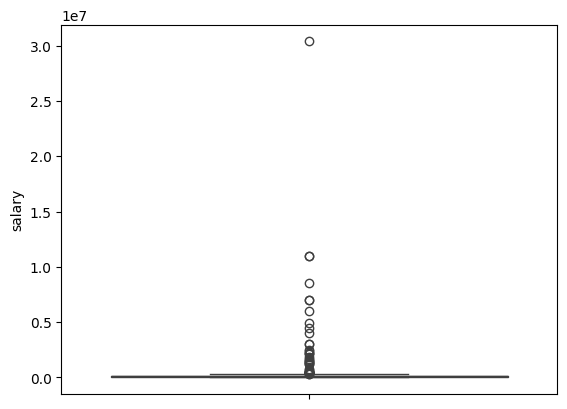

In [15]:
# using boxplot
sns.boxplot(df['salary'])

In [16]:
import plotly.express as px  
fig = px.box(df, y='salary')
fig.show()

In [17]:
#IQR
q1 = df['salary'].quantile(0.25)
q3 = df['salary'].quantile(0.75)
IQR = q3-q1
print("q1:",q1,"q3:",q3)
upper = q3+1.5*IQR
lower = q1-1.5*IQR
print("Upper limit:",upper)
print("lower limit:",lower)



q1: 70000.0 q3: 165000.0
Upper limit: 307500.0
lower limit: -72500.0


In [18]:
# outliers
df.loc[(df['salary']>upper) | (df['salary']<lower)]


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
7,7,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
11,11,2020,MI,FT,Data Scientist,3000000,INR,40481,IN,0,IN,L
16,16,2020,EN,FT,Data Engineer,4450000,JPY,41689,JP,100,JP,S
18,18,2020,EN,FT,Data Science Consultant,423000,INR,5707,IN,50,IN,M
21,21,2020,MI,FT,Product Data Analyst,450000,INR,6072,IN,100,IN,L
25,25,2020,EX,FT,Director of Data Science,325000,USD,325000,US,100,US,L
27,27,2020,SE,FT,Data Engineer,720000,MXN,33511,MX,0,MX,S
33,33,2020,MI,FT,Research Scientist,450000,USD,450000,US,0,US,M
50,50,2020,EN,FT,Data Analyst,450000,INR,6072,IN,0,IN,S
63,63,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L


In [19]:
#trim
new_df1 = df.loc[(df['salary']<upper) & (df['salary']>lower)]
# here we just changed signs to get correct data
print("length of new data:",len(new_df1))
print("length of old data:",len(df))
print("no.of outliers:",len(new_df1)-len(df))

length of new data: 563
length of old data: 607
no.of outliers: -44


### Z score

In [20]:
upper_limit = (df['salary'].mean()) + (3*df['salary'].std())
lower_limit = df['salary'].mean()-3*df['salary'].std()
print("upper limit:",upper_limit)
print("lower limit:",lower_limit)
# print(type(upper_limit))

upper limit: 4957072.5225105155
lower limit: -4309072.397304585


In [21]:
# find outliers
df.loc[(df['salary']>upper_limit) | (df['salary']<lower_limit)]

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
7,7,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
102,102,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
136,136,2021,MI,FT,ML Engineer,7000000,JPY,63711,JP,50,JP,S
137,137,2021,MI,FT,ML Engineer,8500000,JPY,77364,JP,50,JP,S
177,177,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
285,285,2021,SE,FT,Data Science Manager,7000000,INR,94665,IN,50,IN,L
384,384,2022,EX,FT,Head of Machine Learning,6000000,INR,79039,IN,50,IN,L


In [24]:
#trim
new_df2 = df.loc[(df['salary']<upper_limit) & (df['salary']>lower_limit)]
# here we just changed signs to get correct data
print("length of new data:",len(new_df2))
print("length of old data:",len(df))
print("no.of outliers:",len(new_df2)-len(df))

length of new data: 600
length of old data: 607
no.of outliers: -7


### handling outliers
##### 1)trimming -- deleting outlier data

In [25]:
new_df3 = df.loc[(df['salary']<upper_limit) & (df['salary']>lower_limit)]
# here we just changed signs to get correct data
print("length of new data:",len(new_df2))
print("length of old data:",len(df))
print("no.of outliers:",len(new_df2)-len(df))

length of new data: 600
length of old data: 607
no.of outliers: -7


#### filling with central tendencies

C:\Users\Pradnya\AppData\Local\Temp\ipykernel_2156\3425908111.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\Pradnya\AppData\Local\Temp\ipykernel_2156\3425908111.py:11: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '324000.0626029654' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



<Axes: xlabel='salary'>

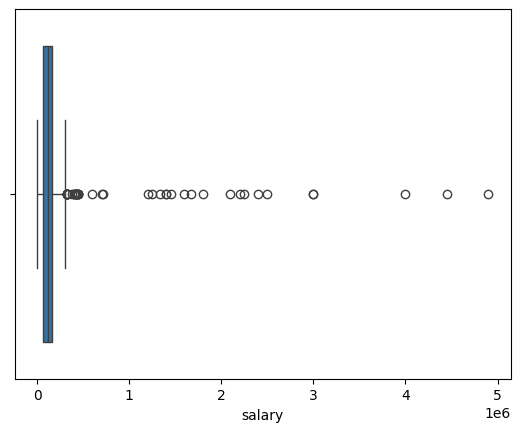

In [43]:
# Fill missing values with the median salary
df['salary'].fillna(df['salary'].median(), inplace=True)

# Create a copy of the DataFrame
new_df3 = df.copy()

# Calculate the mean salary for outlier replacement
mean_salary = df['salary'].mean()

# Replace outliers with the mean salary
new_df3.loc[new_df3['salary'] < lower_limit, 'salary'] = mean_salary
new_df3.loc[new_df3['salary'] > upper_limit, 'salary'] = mean_salary

# Visualize the salary distribution
sns.boxplot(x=new_df3['salary'])




In [44]:
# Display the outliers
outliers = new_df3.loc[(new_df3['salary'] > upper_limit) | (new_df3['salary'] < lower_limit)]
outliers

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
